In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    TimeSeriesSplit,
    GridSearchCV
)

from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
df = pd.read_csv("/content/tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [6]:
print(df.shape)

df.info()

(2640, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [7]:
df.isnull().sum()

,0
Year,0
Month,0
Region,0
Model,0
Estimated_Deliveries,0
Production_Units,0
Avg_Price_USD,0
Battery_Capacity_kWh,0
Range_km,0
CO2_Saved_tons,0


In [8]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)
    + "-"
    + df["Month"].astype(str)
)

df = df.sort_values("Date")

df.head()


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01


In [10]:
df["Lag_1"] = (
    df["Estimated_Deliveries"]
    .shift(1)
)

df["Lag_2"] = (
    df["Estimated_Deliveries"]
    .shift(2)
)

df["Rolling_Mean_3"] = (
    df["Estimated_Deliveries"]
    .rolling(3)
    .mean()
)

df["Rolling_STD_3"] = (
    df["Estimated_Deliveries"]
    .rolling(3)
    .std()
)

df = df.bfill()

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Lag_1,Lag_2,Rolling_Mean_3,Rolling_STD_3
872,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,12446.0,12446.0,10898.333333,1882.237056
2354,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,12446.0,12446.0,10898.333333,1882.237056
2312,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,11446.0,12446.0,10898.333333,1882.237056
2293,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,8803.0,11446.0,8872.000000,2540.202945
2215,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,6367.0,8803.0,7988.333333,1404.121552


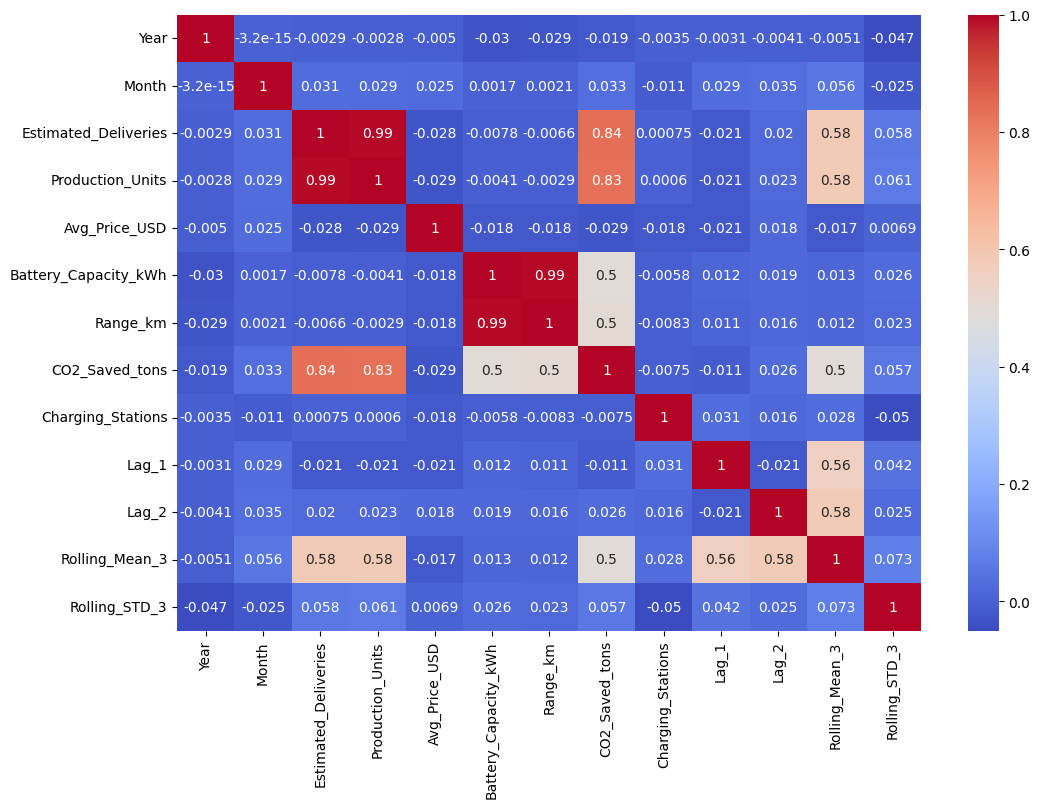

In [11]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

In [12]:
target = "Estimated_Deliveries"

X = df.drop(
    columns=[
        target,
        "Date"
    ]
)

y = df[target]

print(X.shape)
print(y.shape)

(2640, 15)
(2640,)


In [13]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(X_train.shape)
print(X_test.shape)

(2112, 15)
(528, 15)


In [14]:
categorical_cols = X.select_dtypes(
    include=["object"]
).columns

numeric_cols = X.select_dtypes(
    exclude=["object"]
).columns

print(categorical_cols)
print(numeric_cols)

Index(['Region', 'Model', 'Source_Type'], dtype='object')
Index(['Year', 'Month', 'Production_Units', 'Avg_Price_USD',
       'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons',
       'Charging_Stations', 'Lag_1', 'Lag_2', 'Rolling_Mean_3',
       'Rolling_STD_3'],
      dtype='object')


In [15]:
numeric_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    )
])

categorical_transformer = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="most_frequent")
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])

preprocessor = ColumnTransformer([
    (
        "num",
        numeric_transformer,
        numeric_cols
    ),
    (
        "cat",
        categorical_transformer,
        categorical_cols
    )
])

In [16]:
ridge_pipeline = Pipeline([
    (
        "preprocessor",
        preprocessor
    ),
    (
        "model",
        Ridge()
    )
])

In [17]:
param_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1,
        10,
        50,
        100
    ]
}

tscv = TimeSeriesSplit(
    n_splits=5
)

grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=tscv,
    scoring="r2"
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)

{'model__alpha': 0.01}


In [18]:
best_model = grid.best_estimator_

preds = best_model.predict(
    X_test
)

In [19]:
mae = mean_absolute_error(
    y_test,
    preds
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        preds
    )
)

r2 = r2_score(
    y_test,
    preds
)

print("MAE :", mae)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 37.64170874375949
RMSE : 45.83524549372305
R2 : 0.9998419868006166


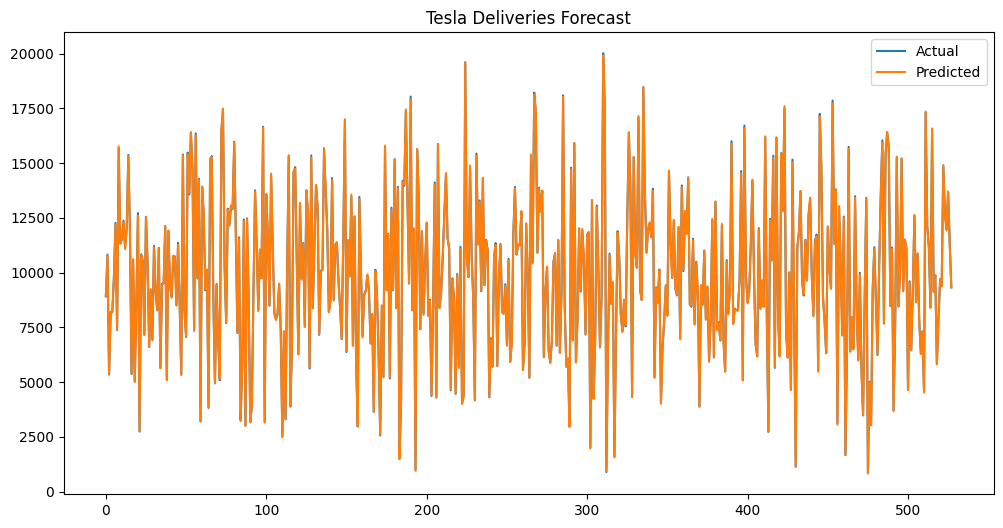

In [20]:
plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    preds,
    label="Predicted"
)

plt.legend()

plt.title(
    "Tesla Deliveries Forecast"
)

plt.show()

In [21]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df["Estimated_Deliveries"])

print("ADF Statistic:", result[0])
print("P-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Non-Stationary")

ADF Statistic: -28.17620446835788
P-value: 0.0
Series is Stationary


In [22]:
forecast_df = pd.DataFrame({
    "Actual": y_test.values[:20],
    "Predicted": preds[:20]
})

forecast_df

,Actual,Predicted
0,8910,8941.804751
1,10819,10780.657456
2,5341,5361.212241
3,8195,8170.469402
4,8179,8204.898508
5,9742,9741.038816
6,12266,12207.031636
7,7375,7412.486707
8,15680,15758.887572
9,11323,11323.479493


# End-to-End Machine Learning Pipeline on Tesla Deliveries Data

## Objective
Build an end-to-end Machine Learning pipeline using Tesla Deliveries and Production Data (2015–2025) to forecast vehicle deliveries and analyze factors affecting sales trends.

## Topics Covered
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Encoding Techniques (OneHotEncoder)
- Feature Scaling (StandardScaler)
- Machine Learning Pipeline
- Ridge Regression (L2 Regularization)
- Evaluation Metrics (MAE, RMSE, R²)
- Cross Validation (TimeSeriesSplit)
- Hyperparameter Tuning (GridSearchCV)
- Time Series Analysis
- Stationarity Testing (ADF Test)
- Lag Features
- Rolling Statistics
- Forecasting
- Chronological Split
- Data Leakage Prevention

## Feature Engineering
- Lag_1 Feature
- Lag_2 Feature
- Rolling Mean (3)
- Rolling Standard Deviation (3)

## Model Used
- Ridge Regression

## Best Hyperparameters
- Alpha = 0.01

## Results
- MAE = 37.64
- RMSE = 45.84
- R² Score = 0.99984

## Stationarity Test
- ADF Statistic = -28.176
- P-Value = 0.0
- Conclusion: Series is Stationary

## Conclusion
The model successfully forecasts Tesla deliveries with very high accuracy. Feature engineering, time-series validation, and Ridge Regression significantly improved predictive performance while maintaining a proper machine learning pipeline.